In [1]:
import numpy as np


# ============================================================
# Quaternion utilities
# Convention:
#   q = [w, x, y, z]
#   Hamilton product
#   q and -q represent the same rotation
# ============================================================

def q_normalize(q):
    q = np.asarray(q, dtype=float)
    norm = np.linalg.norm(q)

    if norm < 1e-15:
        raise ValueError("Zero quaternion")

    return q / norm


def q_conjugate(q):
    q = np.asarray(q, dtype=float)
    return np.array([q[0], -q[1], -q[2], -q[3]])


def q_inverse(q):
    q = np.asarray(q, dtype=float)
    return q_conjugate(q) / np.dot(q, q)


def q_multiply(q1, q2):
    """
    Hamilton quaternion product q = q1 ⊗ q2.
    """
    w1, x1, y1, z1 = q1
    w2, x2, y2, z2 = q2

    return np.array([
        w1*w2 - x1*x2 - y1*y2 - z1*z2,
        w1*x2 + x1*w2 + y1*z2 - z1*y2,
        w1*y2 - x1*z2 + y1*w2 + z1*x2,
        w1*z2 + x1*y2 - y1*x2 + z1*w2
    ])


def skew(v):
    """
    Skew-symmetric matrix such that skew(v) @ a = v × a.
    """
    x, y, z = v

    return np.array([
        [0.0, -z,  y],
        [z,  0.0, -x],
        [-y, x,  0.0]
    ])


def rotvec_to_quaternion(phi):
    """
    Rotation vector [rad] -> quaternion [w, x, y, z].
    """
    phi = np.asarray(phi, dtype=float)
    angle = np.linalg.norm(phi)

    if angle < 1e-12:
        # First-order approximation:
        # dq ≈ [1, phi/2]
        return q_normalize(
            np.array([1.0, 0.5*phi[0], 0.5*phi[1], 0.5*phi[2]])
        )

    axis = phi / angle
    half_angle = 0.5 * angle

    return np.array([
        np.cos(half_angle),
        axis[0] * np.sin(half_angle),
        axis[1] * np.sin(half_angle),
        axis[2] * np.sin(half_angle)
    ])


def quaternion_to_rotvec(q):
    """
    Quaternion [w, x, y, z] -> rotation vector [rad].
    Returns the shortest rotation.
    """
    q = q_normalize(q)

    # Choose the shortest representation
    if q[0] < 0.0:
        q = -q

    vector_part = q[1:]
    vector_norm = np.linalg.norm(vector_part)

    if vector_norm < 1e-12:
        return 2.0 * vector_part

    angle = 2.0 * np.arctan2(vector_norm, q[0])

    return angle * vector_part / vector_norm


# ============================================================
# Gyroless MEKF
# ============================================================

class GyrolessMEKF:
    """
    Multiplicative EKF for attitude estimation without gyroscope.

    Nominal state:
        q       - nominal attitude quaternion
        omega   - estimated angular velocity

    Error state:
        dx = [dtheta_x, dtheta_y, dtheta_z,
              domega_x, domega_y, domega_z]

    Measurement:
        q_measurement - quaternion obtained from image

    Convention:
        q = [w, x, y, z]
        q_true = dq_error ⊗ q_nominal
        angular velocity is expressed in body frame
    """

    def __init__(
        self,
        q0,
        omega0=None,
        P0=None,
        sigma_omega=np.deg2rad(1.0),
        sigma_measurement=np.deg2rad(1.0)
    ):
        self.q = q_normalize(q0)

        if omega0 is None:
            self.omega = np.zeros(3)
        else:
            self.omega = np.asarray(omega0, dtype=float).copy()

        if P0 is None:
            attitude_variance = np.deg2rad(10.0)**2
            angular_rate_variance = np.deg2rad(5.0)**2

            self.P = np.diag([
                attitude_variance,
                attitude_variance,
                attitude_variance,
                angular_rate_variance,
                angular_rate_variance,
                angular_rate_variance
            ])
        else:
            self.P = np.asarray(P0, dtype=float).copy()

        # Standard deviation of angular-rate random walk
        self.sigma_omega = float(sigma_omega)

        # Standard deviation of quaternion measurement,
        # represented as a small rotation angle
        self.sigma_measurement = float(sigma_measurement)

    def predict(self, dt):
        """
        Prediction step.

        Angular model:
            omega(k+1) = omega(k) + noise

        Attitude model:
            q(k+1) = delta_q(omega * dt) ⊗ q(k)
        """
        dt = float(dt)

        if dt <= 0.0:
            raise ValueError("dt must be positive")

        # Propagate nominal quaternion
        delta_angle = self.omega * dt
        delta_q = rotvec_to_quaternion(delta_angle)

        self.q = q_normalize(
            q_multiply(delta_q, self.q)
        )

        # Error-state transition matrix
        I3 = np.eye(3)
        Z3 = np.zeros((3, 3))

        F = np.block([
            [I3, dt * I3],
            [Z3, I3]
        ])

        # Continuous white-noise angular acceleration model
        sigma2 = self.sigma_omega**2

        Q = sigma2 * np.block([
            [(dt**3 / 3.0) * I3, (dt**2 / 2.0) * I3],
            [(dt**2 / 2.0) * I3, dt * I3]
        ])

        # Propagate covariance
        self.P = F @ self.P @ F.T + Q

        # Numerical symmetrization
        self.P = 0.5 * (self.P + self.P.T)

    def update(self, q_measurement, gate_threshold=None):
        """
        Measurement update from image quaternion.

        Returns:
            accepted    - whether measurement was accepted
            innovation  - rotation-vector residual [rad]
            nis         - normalized innovation squared
        """
        q_measurement = q_normalize(q_measurement)

        # q and -q describe the same rotation.
        # Select the representation closest to current estimate.
        if np.dot(q_measurement, self.q) < 0.0:
            q_measurement = -q_measurement

        # Measurement error:
        #
        # q_error = q_measurement ⊗ inverse(q_predicted)
        #
        # For small errors:
        # innovation ≈ dtheta
        q_error = q_multiply(
            q_measurement,
            q_inverse(self.q)
        )

        innovation = quaternion_to_rotvec(q_error)

        # Measurement model:
        #
        # z = [dtheta_x, dtheta_y, dtheta_z]
        #
        H = np.hstack([
            np.eye(3),
            np.zeros((3, 3))
        ])

        R = (
            self.sigma_measurement**2
            * np.eye(3)
        )

        S = H @ self.P @ H.T + R

        # Normalized Innovation Squared
        nis = float(
            innovation @ np.linalg.solve(S, innovation)
        )

        # Optional outlier rejection
        if gate_threshold is not None and nis > gate_threshold:
            return False, innovation, nis

        # Kalman gain
        K = self.P @ H.T @ np.linalg.inv(S)

        # Error-state correction
        dx = K @ innovation

        dtheta = dx[0:3]
        domega = dx[3:6]

        # Inject attitude correction multiplicatively
        dq_correction = rotvec_to_quaternion(dtheta)

        self.q = q_normalize(
            q_multiply(dq_correction, self.q)
        )

        # Correct angular-rate estimate
        self.omega = self.omega + domega

        # Joseph covariance update
        I6 = np.eye(6)
        A = I6 - K @ H

        P_update = (
            A @ self.P @ A.T
            + K @ R @ K.T
        )

        # Error-state reset after injecting dtheta into q.
        #
        # First-order reset Jacobian.
        G = np.eye(6)
        G[0:3, 0:3] -= 0.5 * skew(dtheta)

        self.P = G @ P_update @ G.T

        # Numerical symmetrization
        self.P = 0.5 * (self.P + self.P.T)

        return True, innovation, nis

    def get_state(self):
        """
        Returns a copy of the current nominal state.
        """
        return self.q.copy(), self.omega.copy(), self.P.copy()


# ============================================================
# Synthetic test
# ============================================================

def test_gyroless_mekf():
    rng = np.random.default_rng(7)

    dt = 0.02
    steps = 1500

    # True initial orientation
    q_true = np.array([1.0, 0.0, 0.0, 0.0])

    # Initial true angular velocity
    omega_true = np.deg2rad(
        np.array([1.5, -0.8, 2.0])
    )

    # Initial estimate has a large attitude error
    q_initial_error = rotvec_to_quaternion(
        np.deg2rad(np.array([12.0, -8.0, 10.0]))
    )

    q_initial = q_multiply(
        q_initial_error,
        q_true
    )

    mekf = GyrolessMEKF(
        q0=q_initial,
        omega0=np.zeros(3),
        sigma_omega=np.deg2rad(1.0),
        sigma_measurement=np.deg2rad(0.8)
    )

    accepted_measurements = 0
    rejected_measurements = 0

    for k in range(steps):
        # Slowly changing true angular velocity
        omega_true += rng.normal(
            loc=0.0,
            scale=np.deg2rad(0.015),
            size=3
        )

        # True attitude propagation
        q_true = q_normalize(
            q_multiply(
                rotvec_to_quaternion(omega_true * dt),
                q_true
            )
        )

        # Prediction
        mekf.predict(dt)

        # Simulated image-based quaternion measurement
        measurement_noise = rng.normal(
            loc=0.0,
            scale=np.deg2rad(0.8),
            size=3
        )

        q_measurement = q_normalize(
            q_multiply(
                rotvec_to_quaternion(measurement_noise),
                q_true
            )
        )

        # Measurement update
        accepted, innovation, nis = mekf.update(
            q_measurement,
            gate_threshold=11.34
        )

        if accepted:
            accepted_measurements += 1
        else:
            rejected_measurements += 1

    # Final attitude error
    q_error_final = q_multiply(
        q_true,
        q_inverse(mekf.q)
    )

    attitude_error_deg = np.rad2deg(
        np.linalg.norm(
            quaternion_to_rotvec(q_error_final)
        )
    )

    angular_rate_error_deg_s = np.rad2deg(
        np.linalg.norm(omega_true - mekf.omega)
    )

    print("========== TEST RESULT ==========")
    print(f"True quaternion:       {q_true}")
    print(f"Estimated quaternion:  {mekf.q}")
    print()
    print(f"True omega [deg/s]:    {np.rad2deg(omega_true)}")
    print(f"Estimated omega:       {np.rad2deg(mekf.omega)}")
    print()
    print(
        f"Attitude error:        "
        f"{attitude_error_deg:.3f} deg"
    )
    print(
        f"Angular-rate error:    "
        f"{angular_rate_error_deg_s:.3f} deg/s"
    )
    print()
    print(f"Accepted measurements: {accepted_measurements}")
    print(f"Rejected measurements: {rejected_measurements}")

    # Basic test conditions
    assert np.isfinite(attitude_error_deg)
    assert np.isfinite(angular_rate_error_deg_s)

    # These thresholds are intentionally not too strict.
    assert attitude_error_deg < 2.0
    assert angular_rate_error_deg_s < 1.0

    print()
    print("TEST PASSED")


if __name__ == "__main__":
    test_gyroless_mekf()

========== TEST RESULT ==========
True quaternion:       [ 0.72049067  0.34363815 -0.2944685   0.52544678]
Estimated quaternion:  [ 0.72249764  0.34038372 -0.29277707  0.52575437]

True omega [deg/s]:    [ 0.76243039 -1.30986255  2.31159215]
Estimated omega:       [ 0.29620512 -1.2955134   2.15246276]

Attitude error:        0.480 deg
Angular-rate error:    0.493 deg/s

Accepted measurements: 1484
Rejected measurements: 16

TEST PASSED


========== TEST RESULT ==========
Final attitude error: 0.480 deg
Final angular-rate error: 0.493 deg/s
Accepted measurements: 1484
Rejected measurements: 16


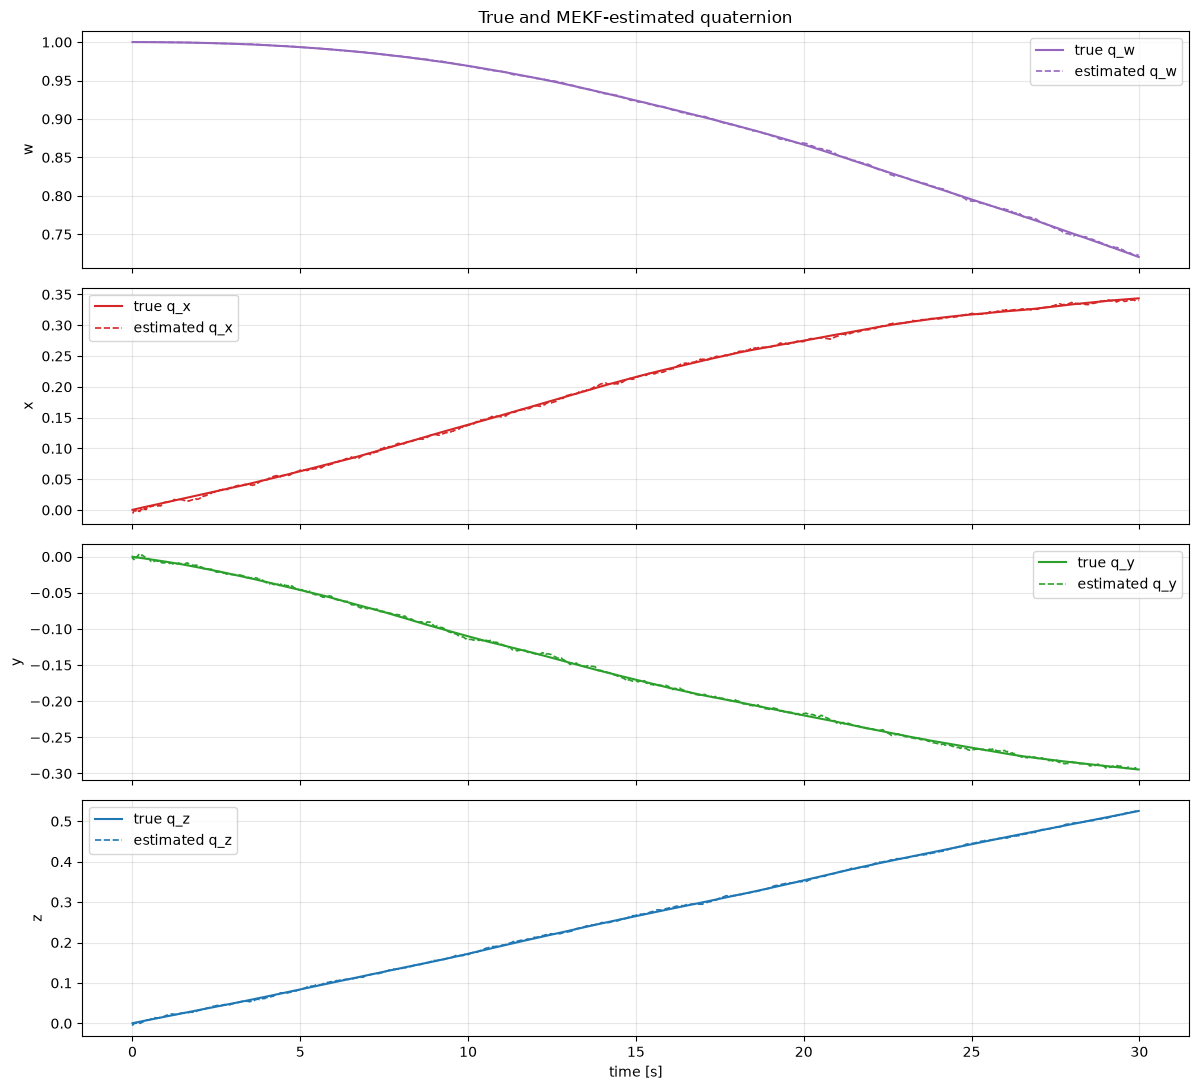

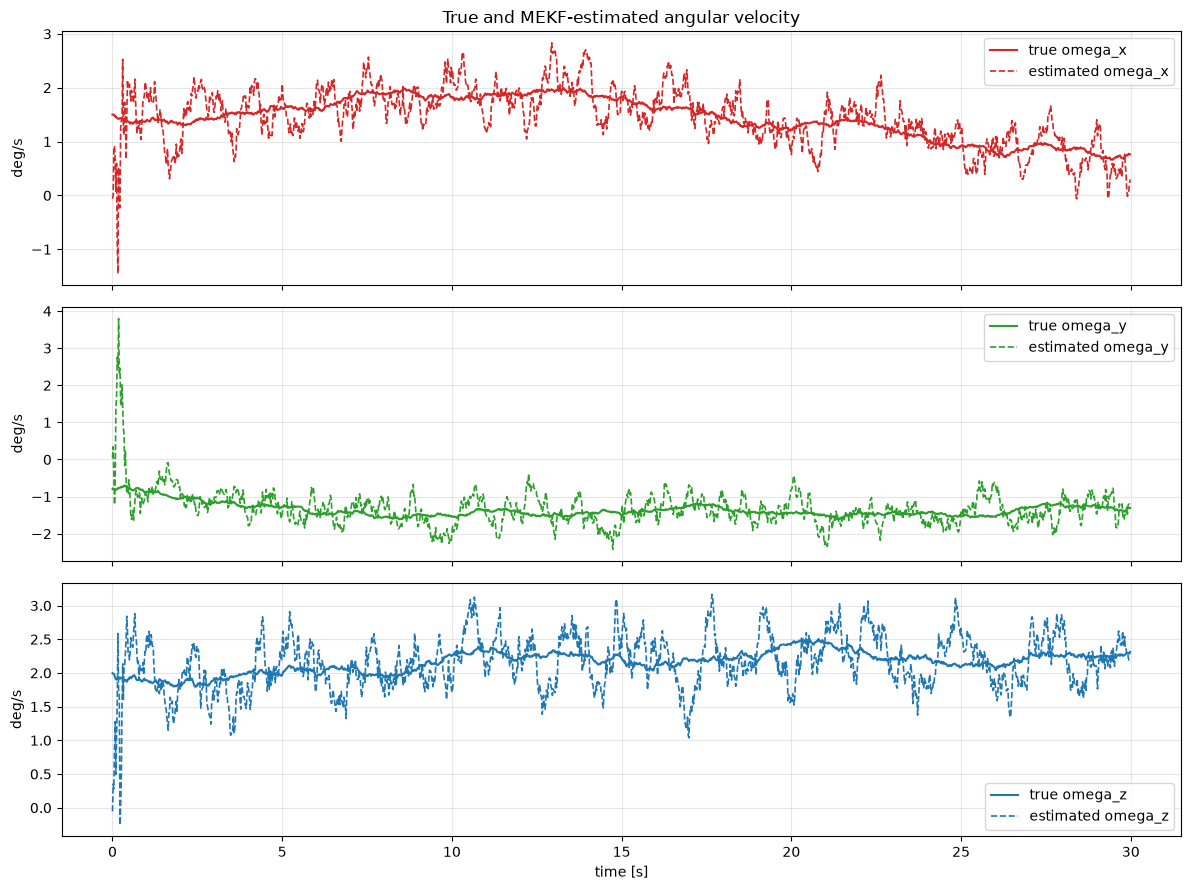

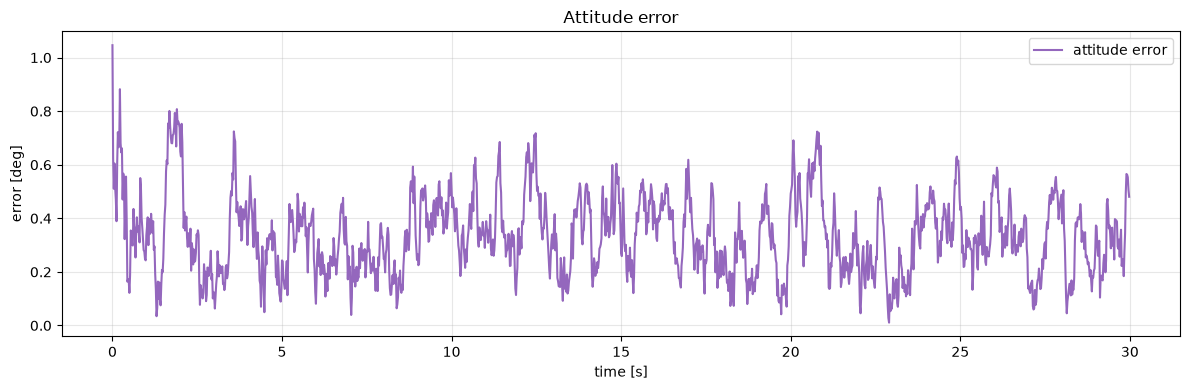


Saved files:
  quaternion_true_vs_estimated.png
  omega_true_vs_estimated.png
  attitude_error.png
  mekf_quaternion_omega_data.csv


In [3]:
import numpy as np
import matplotlib.pyplot as plt


def run_test_and_plot():
    rng = np.random.default_rng(7)

    dt = 0.02
    steps = 1500
    time = np.arange(steps) * dt

    # ========================================================
    # Истинное начальное состояние
    # ========================================================

    q_true = np.array([
        1.0,
        0.0,
        0.0,
        0.0
    ])

    omega_true = np.deg2rad(
        np.array([
            1.5,
            -0.8,
            2.0
        ])
    )

    # ========================================================
    # Начальное приближение фильтра
    # ========================================================

    initial_error = rotvec_to_quaternion(
        np.deg2rad([
            12.0,
            -8.0,
            10.0
        ])
    )

    q_initial = q_multiply(
        initial_error,
        q_true
    )

    mekf = GyrolessMEKF(
        q0=q_initial,
        omega0=np.zeros(3),
        sigma_omega=np.deg2rad(1.0),
        sigma_measurement=np.deg2rad(0.8)
    )

    # ========================================================
    # Истории данных
    # ========================================================

    q_true_history = []
    q_estimated_history = []

    omega_true_history = []
    omega_estimated_history = []

    attitude_error_history = []
    nis_history = []
    accepted_history = []

    # ========================================================
    # Основной цикл моделирования
    # ========================================================

    for k in range(steps):

        # ----------------------------------------------------
        # Изменение истинной угловой скорости
        # ----------------------------------------------------

        omega_true += rng.normal(
            loc=0.0,
            scale=np.deg2rad(0.015),
            size=3
        )

        # ----------------------------------------------------
        # Распространение истинного кватерниона
        # ----------------------------------------------------

        delta_q_true = rotvec_to_quaternion(
            omega_true * dt
        )

        q_true = q_normalize(
            q_multiply(
                delta_q_true,
                q_true
            )
        )

        # ----------------------------------------------------
        # Прогноз MEKF
        # ----------------------------------------------------

        mekf.predict(dt)

        # ----------------------------------------------------
        # Имитация измерения кватерниона от изображения
        # ----------------------------------------------------

        measurement_noise = rng.normal(
            loc=0.0,
            scale=np.deg2rad(0.8),
            size=3
        )

        q_measurement = q_normalize(
            q_multiply(
                rotvec_to_quaternion(measurement_noise),
                q_true
            )
        )

        # ----------------------------------------------------
        # Коррекция MEKF
        # ----------------------------------------------------

        accepted, innovation, nis = mekf.update(
            q_measurement,
            gate_threshold=11.34
        )

        # ----------------------------------------------------
        # Сохраняем кватернионы для графика
        # ----------------------------------------------------

        q_true_plot = q_true.copy()
        q_estimated_plot = mekf.q.copy()

        # q и -q описывают одну ориентацию.
        # Выбираем одинаковый знак для корректного графика.
        if np.dot(q_true_plot, q_estimated_plot) < 0.0:
            q_estimated_plot = -q_estimated_plot

        q_true_history.append(q_true_plot)
        q_estimated_history.append(q_estimated_plot)

        # ----------------------------------------------------
        # Сохраняем угловые скорости
        # ----------------------------------------------------

        omega_true_history.append(
            np.rad2deg(omega_true.copy())
        )

        omega_estimated_history.append(
            np.rad2deg(mekf.omega.copy())
        )

        # ----------------------------------------------------
        # Ошибка ориентации
        # ----------------------------------------------------

        q_error = q_multiply(
            q_true,
            q_inverse(mekf.q)
        )

        attitude_error = np.rad2deg(
            np.linalg.norm(
                quaternion_to_rotvec(q_error)
            )
        )

        attitude_error_history.append(
            attitude_error
        )

        nis_history.append(nis)
        accepted_history.append(accepted)

    # ========================================================
    # Преобразуем историю в numpy-массивы
    # ========================================================

    q_true_history = np.asarray(
        q_true_history
    )

    q_estimated_history = np.asarray(
        q_estimated_history
    )

    omega_true_history = np.asarray(
        omega_true_history
    )

    omega_estimated_history = np.asarray(
        omega_estimated_history
    )

    attitude_error_history = np.asarray(
        attitude_error_history
    )

    nis_history = np.asarray(
        nis_history
    )

    accepted_history = np.asarray(
        accepted_history
    )

    # ========================================================
    # Вывод результатов
    # ========================================================

    final_attitude_error = attitude_error_history[-1]

    final_omega_error = np.linalg.norm(
        omega_true_history[-1]
        - omega_estimated_history[-1]
    )

    rejected_count = np.count_nonzero(
        ~accepted_history
    )

    print("========== TEST RESULT ==========")

    print(
        f"Final attitude error: "
        f"{final_attitude_error:.3f} deg"
    )

    print(
        f"Final angular-rate error: "
        f"{final_omega_error:.3f} deg/s"
    )

    print(
        f"Accepted measurements: "
        f"{np.count_nonzero(accepted_history)}"
    )

    print(
        f"Rejected measurements: "
        f"{rejected_count}"
    )

    # ========================================================
    # График 1: истинный и уточнённый кватернион
    # ========================================================

    quaternion_names = [
        "w",
        "x",
        "y",
        "z"
    ]

    quaternion_colors = [
        "tab:purple",
        "tab:red",
        "tab:green",
        "tab:blue"
    ]

    fig_q, axes_q = plt.subplots(
        4,
        1,
        figsize=(12, 11),
        sharex=True
    )

    for i in range(4):

        axes_q[i].plot(
            time,
            q_true_history[:, i],
            color=quaternion_colors[i],
            linewidth=1.5,
            label=f"true q_{quaternion_names[i]}"
        )

        axes_q[i].plot(
            time,
            q_estimated_history[:, i],
            color=quaternion_colors[i],
            linestyle="--",
            linewidth=1.2,
            label=f"estimated q_{quaternion_names[i]}"
        )

        axes_q[i].set_ylabel(
            quaternion_names[i]
        )

        axes_q[i].grid(
            True,
            alpha=0.3
        )

        axes_q[i].legend(
            loc="best"
        )

    axes_q[0].set_title(
        "True and MEKF-estimated quaternion"
    )

    axes_q[-1].set_xlabel(
        "time [s]"
    )

    fig_q.tight_layout()

    fig_q.savefig(
        "quaternion_true_vs_estimated.png",
        dpi=160,
        bbox_inches="tight"
    )

    # ========================================================
    # График 2: истинная и уточнённая угловая скорость
    # ========================================================

    omega_names = [
        "x",
        "y",
        "z"
    ]

    omega_colors = [
        "tab:red",
        "tab:green",
        "tab:blue"
    ]

    fig_omega, axes_omega = plt.subplots(
        3,
        1,
        figsize=(12, 9),
        sharex=True
    )

    for i in range(3):

        axes_omega[i].plot(
            time,
            omega_true_history[:, i],
            color=omega_colors[i],
            linewidth=1.5,
            label=f"true omega_{omega_names[i]}"
        )

        axes_omega[i].plot(
            time,
            omega_estimated_history[:, i],
            color=omega_colors[i],
            linestyle="--",
            linewidth=1.2,
            label=f"estimated omega_{omega_names[i]}"
        )

        axes_omega[i].set_ylabel(
            "deg/s"
        )

        axes_omega[i].grid(
            True,
            alpha=0.3
        )

        axes_omega[i].legend(
            loc="best"
        )

    axes_omega[0].set_title(
        "True and MEKF-estimated angular velocity"
    )

    axes_omega[-1].set_xlabel(
        "time [s]"
    )

    fig_omega.tight_layout()

    fig_omega.savefig(
        "omega_true_vs_estimated.png",
        dpi=160,
        bbox_inches="tight"
    )

    # ========================================================
    # Дополнительный график ошибки ориентации
    # ========================================================

    fig_error, ax_error = plt.subplots(
        figsize=(12, 4)
    )

    ax_error.plot(
        time,
        attitude_error_history,
        color="tab:purple",
        linewidth=1.5,
        label="attitude error"
    )

    ax_error.set_title(
        "Attitude error"
    )

    ax_error.set_xlabel(
        "time [s]"
    )

    ax_error.set_ylabel(
        "error [deg]"
    )

    ax_error.grid(
        True,
        alpha=0.3
    )

    ax_error.legend()

    fig_error.tight_layout()

    fig_error.savefig(
        "attitude_error.png",
        dpi=160,
        bbox_inches="tight"
    )

    # ========================================================
    # Показать графики
    # ========================================================

    plt.show()

    # ========================================================
    # Сохранить данные в CSV
    # ========================================================

    data = np.column_stack([
        time,

        q_true_history,
        q_estimated_history,

        omega_true_history,
        omega_estimated_history,

        attitude_error_history,
        nis_history,

        accepted_history.astype(int)
    ])

    header = (
        "time,"

        "qw_true,qx_true,qy_true,qz_true,"
        "qw_est,qx_est,qy_est,qz_est,"

        "wx_true,wy_true,wz_true,"
        "wx_est,wy_est,wz_est,"

        "attitude_error_deg,"
        "nis,"
        "measurement_accepted"
    )

    np.savetxt(
        "mekf_quaternion_omega_data.csv",
        data,
        delimiter=",",
        header=header,
        comments=""
    )

    print()
    print("Saved files:")
    print("  quaternion_true_vs_estimated.png")
    print("  omega_true_vs_estimated.png")
    print("  attitude_error.png")
    print("  mekf_quaternion_omega_data.csv")


if __name__ == "__main__":
    run_test_and_plot()